# Linear Regression


Reference: 
- [ML-linear-regression-notebook](https://github.com/crsmithdev/notebooks/blob/master/ml-linear-regression/ml-linear-regression.ipynb)
- [Andrew NG ML Specialization Course]()

# 2.1. Single Variable Linear Regression

i.e., One input variable/feature and one output variable/target

So, Our model: $$ y = wX+b$$

Where, 
- X : input to the model
- y : output of the model for the given input X
- w,b : parameters for best fit and are referred as $\theta$ for ease of use. 


The graph for the task is shown as below: 

<!-- ![linear-regression-figure](https://www.researchgate.net/profile/Burak-Oeztornaci/publication/381857634/figure/fig1/AS:11431281257626828@1719839742106/Linear-regression-model.png) -->
<!-- ![linear-regression-figure](images/Linear-regression-model.png) -->
![linear-regression-figure](../../Old_Syllabus/Lab2-LinearRegression/images/Linear-regression-model.png)

Here, 
- x-axis: input/features
- y-axis: target/output/labels (value to be predicted)


**Definition**:

- `Linear regression` is a simple approach to supervised learning. It assumes that the dependence of 𝑌 on 𝑥1, 𝑥2,…,$𝑥_𝑛$ is linear. 

- `Linear regression` is a fundamental statistical and machine learning technique used to model the relationship between a dependent (target) variable and one or more independent (predictor) variables. The goal is to **fit a linear model to the data that best predicts the target variable**.

In [4]:
# Loading 
import pandas as pd

data = pd.read_csv("./data.csv")
hours = data['Hours_Studied'].values
scores = data['Exam_Score'].values

In [5]:
print(f'hours shape: {hours.shape}, scores shape: {scores.shape}')

hours shape: (106,), scores shape: (106,)


In [6]:
pd.Series(hours).describe() # convert to a pandas Series to use describe()

count    106.000000
mean       5.268868
std        2.746708
min        0.500000
25%        2.925000
50%        5.275000
75%        7.575000
max       10.000000
dtype: float64

Here, the feature is already normalized. 

In [7]:
pd.Series(scores).describe()

count    106.000000
mean      77.603774
std       16.049138
min       48.000000
25%       64.000000
50%       78.000000
75%       92.000000
max      100.000000
dtype: float64

Here, the scale of the two series is different, so converting it to the same scale.  

Data has no missing values. However, the scale is different so scaling the `scores` feature. 

Let's visualize the data: 

Text(0, 0.5, 'Exam Scores')

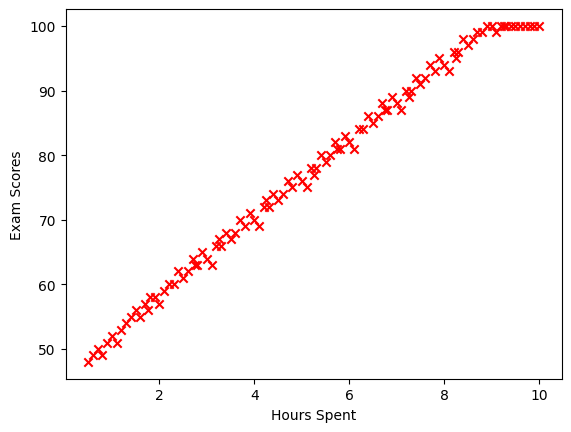

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(hours, scores, marker='x', color='red')
plt.xlabel('Hours Spent')
plt.ylabel('Exam Scores')

<!-- ### 2. Feature Design -->

Here, we have two columns, if we consider one as input/feature and the other as the output/labels then we do not require `Feature Designing.`

<!-- ### 3. Algorithm Selection -->

Here, the target is a numeric and not class/category, therefore it is a regression task. A simple regression task i.e. `regression task that take one variable as input and predicts another`. 

Mathematically, 

`Model`:
- model` with single independent variable and single dependent variable : $f_{w,b}(x)=wx+b$

Where,
- x is the independent variable and
- w, b are the parameters to fit/set. (slope and intercept for this case)

![Slope-Intercept](https://s3-us-west-2.amazonaws.com/courses-images-archive-read-only/wp-content/uploads/sites/924/2015/11/25201048/CNX_Precalc_Figure_02_02_0032.jpg)

`Parameters`: $w,b$ 
- This it the variable that we can adjust to improve the model. 
- also called coefficients/weights



![Linear Regression Notation](../../Old_Syllabus/Lab2-LinearRegression/images/notations.png)

Here, 

- $(x^{(i)},y^{(i)})$ is a data point in our dataset, and 
- predicted value for independent variable value $x^{(i)}$ is $\hat{y}^{(i)}$

Our goal in Linear Regression is to **find $w,b$ such that $\hat{y}^{(i)}$ is close to $y^{(i)}$ for all $(x^{(i)},y^{(i)})$**

So how do we do that? 

To do that, let's first understand the cost function: 

Prediction error = $(\hat{y}-y)$

Prediction error for ith value: $(\hat{y}^{(i)}-y^{(i)})$

Here, depending on the which side of the regression line is the label value, the value of prediction error can be positive or negative. Therefore, let's square them. 

Square of Prediction error for ith value: $(\hat{y}^{(i)}-y^{(i)})^2$

Assuming we have $m$ number of input data/values then sum of squared prediction error will be: $\sum^{m}_{i=1}(\hat{y}^{(i)}-y^{(i)})^2$

Then mean will be, $\frac{1}{m} \sum^{m}_{i=1}(\hat{y}^{(i)}-y^{(i)})^2$
+
But in ML, researchers often divide by $2m$ instead of the $m$. 

Why is it the case? Please include the answer to this question by the last lab.

So cost function is: 

$$ J(w,b) = \frac{1}{2m} \sum^{m}_{i=1}(\hat{y}^{(i)}-y^{(i)})^2$$

Also, 

$$ J(w,b) = \frac{1}{2m} \sum^{m}_{i=1}(f_{w,b}((x)^{(i)})-y^{(i)})^2$$


Now, you have the `Squared Error Cost Function`. Also called  [Mean Squared Error (MSE)](https://en.wikipedia.org/wiki/Mean_squared_error).

![MSE](https://cdn-media-1.freecodecamp.org/images/MNskFmGPKuQfMLdmpkT-X7-8w2cJXulP3683)

The objective of the learning algorithm, then, is to find the parameters $w,b$ which give the minimum possible cost `J`.

Again, our goal in Linear Regression is to 
- find $w,b$ such that $\hat{y}^{(i)}$ is close to $y^{(i)}$ for all $(x^{(i)},y^{(i)})$

Mathematically it is written as: 
$$ \underset{w,b}{\text{minimize}} \quad J(w,b)$$

Or if we refer $w$ and $b$ as $\theta$ then it can be written as: 
$$ \underset{\theta}{\text{minimize}} \quad J(\theta)$$




The term `loss function` and `cost function` are used interchangeably , however there is a difference. The loss function measures the error for a single data point, while the cost function is the average of the loss function over the entire dataset. The cost function is typically what is minimized during model training.

In [9]:
# let's code the cost function. 

import numpy as np

def compute_cost(X, y, theta):
    return np.sum(np.square(np.matmul(X, theta) - y)) / (2 * len(y))

Before computing the cost with an initial guess for $w$ and $b$, a column of 1s is prepended onto the input data. This allows us to vectorize the cost function, as well as make it usable for multiple linear regression later. This first value 
$b$ now behaves as a constant in the cost function.

![prepend](../../Old_Syllabus/Lab2-LinearRegression/images/prepend%20columns%20of%201s_0.png)

![prepend](../../Old_Syllabus/Lab2-LinearRegression/images/prepend%20columns%20of%201s_1.png)

In [10]:
theta = np.zeros(2)
X = np.column_stack((np.ones(len(hours)), hours)) # first column of 1's for bias
y = scores
print(f'shape of X: {X.shape}\nshape of y: {y.shape}')
cost = compute_cost(X, y, theta)

print('theta:', theta)
print('cost:', cost)

shape of X: (106, 2)
shape of y: (106,)
theta: [0. 0.]
cost: 3138.745283018868


<!-- ### 5. Model Learning -->

**Gradient descent** is the backbone of the learning process for various algorithms, including linear regression, logistic regression, support vector machines, and neural networks which serves as a fundamental optimization technique to minimize the cost function of a model by **iteratively adjusting the model parameters to reduce the difference between predicted and actual values, improving the model's performance.**

**Gradient Descent Algorithm in short**

![gradient descent single variable](../../Old_Syllabus/Lab2-LinearRegression/images/gradient%20descent%20single%20variable.png)

![2](../../Old_Syllabus/Lab2-LinearRegression/images/gradient%20descent%20single%20variable%202.png)

![3](../../Old_Syllabus/Lab2-LinearRegression/images/gradient%20descent%20single%20variable%203.png)

![4](../../Old_Syllabus/Lab2-LinearRegression/images/gradient%20descent%20single%20variable%204.png)

**Gradient Descent Algorithm for Linear Regression**

Given:
- Training set: $(x^{(i)}, y^{(i)})$ for $i = 1, \dots, m$
- Hypothesis: 
$$
f_{w,b}(x) = wx + b
$$
- Cost function: 
$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^m (wx^{(i)} + b - y^{(i)})^2
$$
- Learning rate: $\alpha$


 **Algorithm for single variable Linear Regression**

1. **Initialize parameters**
   - $w := 0, \quad b := 0$

2. **Repeat until convergence** (or for a fixed number of iterations):

   a. **Compute gradients**
      - $\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^m (wx^{(i)} + b - y^{(i)}) x^{(i)}$
      - $\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (wx^{(i)} + b - y^{(i)}) $

   b. **Update parameters**
      - $w := w - \alpha \frac{\partial J}{\partial w}$
      - $ b := b - \alpha \frac{\partial J}{\partial b} $

3. **Return optimized parameters**
   - $ w, b $


In [11]:
# let's code gradient descent update rule for single variable linear regression
def gradient_descent(X, y, alpha, iterations):
    theta = np.zeros(2)
    m = len(y)
    
    for _ in range(iterations):
        t0 = theta[0] - (alpha / m) * np.sum(np.dot(X, theta) - y)
        t1 = theta[1] - (alpha / m) * np.sum((np.dot(X, theta) - y) * X[:,1])
        theta = np.array([t0, t1])

    return theta

### Vecorized code for the above: 

# def gradient_descent(X, y, alpha, iterations):
#     theta = np.zeros(X.shape[1])
#     m = len(y)

#     for _ in range(iterations):
#         error = X @ theta - y
#         gradient = (1/m) * (X.T @ error)
#         theta = theta - alpha * gradient

#     return theta

In [12]:
iterations = 5000
alpha = 0.1 
# alpha = 1e-6 ## uncomment this and please check what happens

theta = gradient_descent(X, y, alpha, iterations)
cost = compute_cost(X, y, theta)

print("theta:", theta)
print('cost:', compute_cost(X, y, theta))

theta: [nan nan]
cost: nan


/home/crdy/testing/AI_lab/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_12893/671599686.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  t1 = theta[1] - (alpha / m) * np.sum((np.dot(X, theta) - y) * X[:,1])


As, you can see, `we got an issue`. This is because our input and output are not scaled. So let's scale them and try again. 

Reason: 
- Large prediction error initially 
- Large gradient (as gradient is proportional to prediction error.)

Consequence: 
- Learning rate selection becomes hard (require smaller learning rate)
- Training diverges/oscillates

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Fit on training data and transform
hours_scaled = scaler.fit_transform(hours.reshape(-1,1))

X_scaled = np.column_stack((np.ones(len(hours_scaled)), hours_scaled)) # first column of 1's for bias

In [14]:
y_scaled = scaler.fit_transform(y.reshape(-1,1))
y_scaled = y_scaled.reshape(-1)
y_scaled.shape


(106,)

Text(0, 0.5, 'Exam Scores')

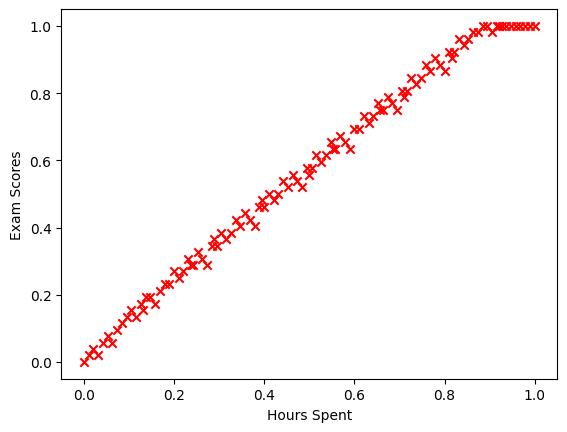

In [15]:
plt.scatter(hours_scaled, y_scaled, marker='x', color='red')
plt.xlabel('Hours Spent')
plt.ylabel('Exam Scores')

Since, we have created a model using scaled dataset, we need to scale it back to original in order to predict using the trained model.

In [16]:
def predict_single(x, theta, x_scaler, y_scaler):
    x_scaled = x_scaler.transform([[x]])  # 2D

    y_scaled = theta[1] * x_scaled + theta[0]

    y = y_scaler.inverse_transform(y_scaled)

    return y[0][0]

def predict_batch(X, theta, x_scaler, y_scaler):
    X = np.array(X).reshape(-1, 1)

    X_scaled = x_scaler.transform(X)

    y_scaled = theta[1] * X_scaled + theta[0]

    y = y_scaler.inverse_transform(y_scaled)

    return y.flatten()

In [17]:
iterations = 50000
alpha = 0.001

theta = gradient_descent(X_scaled, y_scaled, alpha, iterations)
cost = compute_cost(X_scaled, y_scaled, theta)

print("theta:", theta)
print('cost:', compute_cost(X_scaled, y_scaled, theta))

theta: [0.05223117 1.03222088]
cost: 0.0004098041036134282


In [18]:
X_scaled[:,1].shape
y_scaled.shape

(106,)

Text(0, 0.5, 'Exam Score')

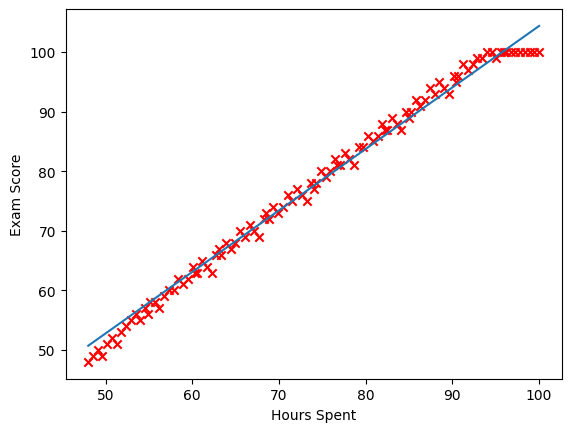

In [19]:
x_scaler = scaler
y_scaler = scaler

X_orig = x_scaler.inverse_transform(X_scaled[:,1].reshape(-1,1)).flatten()
y_orig = y_scaler.inverse_transform(y_scaled.reshape(-1,1)).flatten()

samples_orig = np.linspace(X_orig.min(), X_orig.max(), 100)

samples_scaled = x_scaler.transform(samples_orig.reshape(-1,1)).flatten()

y_line_scaled = theta[0] + theta[1] * samples_scaled
y_line_orig = y_scaler.inverse_transform(y_line_scaled.reshape(-1,1)).flatten()

plt.scatter(X_orig, y_orig, marker='x', color='red')
plt.plot(samples_orig, y_line_orig)
plt.xlabel('Hours Spent')
plt.ylabel('Exam Score')

**How contour plot are made**
<!-- 1X2 grid -->

<!-- uncomment this to see the image -->
<!-- ![first image](https://pressbooks.bccampus.ca/geolmanual/wp-content/uploads/sites/1073/2020/07/profile_howto-768x671.png) -->

![contour](https://gisgeography.com/wp-content/uploads/2017/01/Contours-768x516.png)


# Multi Variabla Linear Regresssion

The next step is to implement gradient descent for any number of features. Fortunately, the update step generalizes easily, and can be vectorized to avoid iterating through $\theta_j$ 
 values as might be suggested by the single variable implementation above:

![Gradient Descent Equations](images/gradient_descent_equations.png)

As we can see above, we can similarly write code to train multiple variable linear regression model. 

However, here we are going to use the `LinearRegression` model from `scikit-learn`. 

In [20]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse

# Load data
data = pd.read_csv("./data.csv")
X = data[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Practice_Tests', 'Stress_Level']].values
y = data['Exam_Score'].values   # scale down

# Feature normalization (standardization)
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Create linear regression model
model = LinearRegression()
model.fit(X_scaled, y) # here, we do not need to add the intercept column

# Get the learned weights and bias
print("Bias (intercept):", model.intercept_)
print("Weights (coefficients):", model.coef_)

# Optional: predict
y_pred = model.predict(X_scaled)

error = mse(y, y_pred)

print(f'MSE: {error}')

Bias (intercept): 77.60377358490567
Weights (coefficients): [15.98550164  4.37783927 -2.91418842 -2.06433001 -0.61526235]
MSE: 1.1625918814027274


`sklearn.LinearRegression` does not need `y` or `X` scaling because it does not use gradient descent. Instead of gradually updating weights using a learning rate, it computes the optimal coefficients directly using linear algebra methods (such as least-squares solvers based on SVD/QR decompositions). In gradient descent, a large target value (e.g., around 10,000) produces large errors and gradients, which can make training unstable unless you reduce the learning rate or scale `y`. Since scikit-learn's solver does not take iterative steps or use a learning rate, it is largely unaffected by the scale of the target and can directly find the best-fitting line without requiring `y` standardization.